# Week 4: NLP Disaster Tweets Kaggle Mini-Project

## 1) Introduction

My startpoint was the starter notebook provided by the Keras team. https://keras.io/guides/keras_nlp/getting_started/

The starter notebook uses the DistilBERT pretrained model from KerasNLP.  **BERT** stands for **Bidirectional Encoder Representations from Transformers**. BERT and other Transformer encoder architectures have been wildly successful on a variety of tasks in NLP (natural language processing). They compute vector-space representations of natural language that are suitable for use in deep learning models. The BERT family of models uses the **Transformer encoder architecture** to process each token of input text in the full context of all tokens before and after, hence the name: Bidirectional Encoder Representations from Transformers. BERT models are usually pre-trained on a large corpus of text, then fine-tuned for specific tasks. **DistilBERT model** is a distilled form of the **BERT** model. The size of a BERT model was reduced by 40% via knowledge distillation during the pre-training phase while retaining 97% of its language understanding abilities and being 60% faster.

This will be one of the models I use, but, looking at the project instructions: I will also look at one other "build from scratch" GRU type model.

In [2]:
import os
import sys
import glob
import time
from pathlib import Path
from datetime import datetime
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from tqdm import tqdm
import gc
import random
import re
import string
import operator
from collections import defaultdict
from wordcloud import STOPWORDS

import platform

os.environ['KERAS_BACKEND'] = 'tensorflow'
import tensorflow as tf

from tensorflow.keras import mixed_precision
from tensorflow import keras
import keras_nlp

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
# for building the preprocessor for the GRU model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

AUTO = tf.data.experimental.AUTOTUNE #not sure if this is needed in this model, I did it previously to help performance

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split


# Determine if we're running locally or in Kaggle'
KAGGLE_ENV = os.path.exists('/kaggle/input')
if KAGGLE_ENV:
    print("Using Kaggle competition data")
    DATA_DIR = Path('/kaggle/input/nlp-getting-started')
else:
    print("Running locally with downloaded Kaggle data")
    DATA_DIR = Path("nlp-getting-started")

    # Set up for Apple Silicon GPU acceleration - locally I run a MacBook Pro M1
    is_macos = platform.system() == "Darwin"
    if is_macos:
        print(f"Running on macOS: {is_macos}")

        USE_MIXED_PRECISION = False  # Not always a good idea, so use variable to turn on/off

        # Enable GPU acceleration if available
        print("Metal GPU Available: ", len(tf.config.list_physical_devices('GPU')) > 0)
        if tf.config.list_physical_devices('GPU'):
            print("Using GPU acceleration with Metal")
            for gpu in tf.config.list_physical_devices('GPU'):
                tf.config.experimental.set_memory_growth(gpu, True)
        else:
            print("GPU not available, using CPU")
        # Enable mixed precision policy
        if USE_MIXED_PRECISION:
            policy = mixed_precision.Policy('mixed_float16')
        else:
            policy = mixed_precision.Policy('float32')
        mixed_precision.set_global_policy(policy)
        print(f"Mixed precision policy set to: {policy}")

print("Python:", sys.version.split()[0])
print("TensorFlow version:", tf.__version__)
print("KerasNLP version:", keras_nlp.__version__)

Running locally with downloaded Kaggle data
Running on macOS: True
Metal GPU Available:  True
Using GPU acceleration with Metal
Mixed precision policy set to: <DTypePolicy "float32">
Python: 3.11.13
TensorFlow version: 2.19.1
KerasNLP version: 0.22.2


In [2]:
# Handle other imports and project setup requirements

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# paths
OUTPUT_DIR = Path("./outputs/5511_module4")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR = Path("./figs/5511_module4")
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODEL_DIR = Path("./models/5511_module4")
MODEL_DIR.mkdir(exist_ok=True, parents=True)

# Plotting defaults
sns.set_theme(context="notebook", style="darkgrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

# helper function to save figures
def save_figure(name=None, dpi=300, bbox_inches='tight', pad_inches=0.1):
    # Generate filename
    if name is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"chart_{timestamp}.png"
    else:
        # Clean the name to be filename-safe
        filename = "".join(c for c in name if c.isalnum() or c in (' ', '-', '_')).rstrip()
        filename = filename.replace(' ', '_')
        if not filename.endswith('.png'):
            filename += '.png'
    # Full path
    filepath = os.path.join(FIG_DIR, filename)
    # Save the figure
    plt.savefig(filepath, dpi=dpi, bbox_inches=bbox_inches, pad_inches=pad_inches)
    print(f"Figure saved: {filepath}")
    return filepath

# Import tokenization - a python module from Guines Evitan's Kaggle notebook' (see citations)
current_dir = os.getcwd()
src_path = os.path.join(current_dir, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
try:
    from nlp import tokenization
    from nlp.tweet_cleaner import clean_tweet
    print("Successfully imported tokenization and cleaning module")
except ImportError as e:
    print(f"Failed to import tokenization: {e}")

# helper function to save model
def save_model(model, model_name, model_dir=MODEL_DIR):
    model_path = os.path.join(model_dir, model_name)
    model.save(model_path)
    print(f"Model saved: {model_path}")
    return model_path

# helper function to load model
def load_model(model_name, model_dir=MODEL_DIR):
    model_path = os.path.join(model_dir, model_name)
    model = tf.keras.models.load_model(model_path)
    print(f"Model loaded: {model_path}")
    return model

# helper function to display confusion matrix and returns F1 score for a given dataset and model
def displayConfusionMatrix(y_true, y_pred, dataset, model_name="DistilBERT"):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true,
        np.argmax(y_pred, axis=1),
        display_labels=["Not Disaster","Disaster"],
        cmap=plt.cm.Blues
    )
    tn, fp, fn, tp = confusion_matrix(y_true, np.argmax(y_pred, axis=1)).ravel()
    f1_score = tp / (tp+((fn+fp)/2))
    disp.ax_.set_title(f"Confusion Matrix for {model_name} on {dataset} -- F1 Score: {str(f1_score.round(2))}")
    plt.tight_layout
    save_figure(f"Confusion Matrix for {model_name} on {dataset}")
    plt.show()
    return f1_score

Successfully imported tokenization and cleaning module


## 2) Brief description of the problem and data
_Briefly describe the challenge problem and NLP. Describe the size, dimension, structure, etc., of the data._


### Challenge Problem
In the Kaggle competition, the challenge is to build an NLP machine learning model that predicts which Tweets are about real disasters and which ones aren’t.

In addition, the project scoring rubrik requires various criteria are met. These are set out in _italics_ under each section heading.

The data is available in two files:
- train.csv: 10,000 tweets that were hand-classified
- test.csv: 10,000 tweets that were not hand-classified

### Data Description
- id
- keyword: A keyword from that tweet (although this may be blank!)
- location: The location the tweet was sent from (may also be blank)
- text: The text of a tweet
- target: 1 if the tweet is a real disaster or 0 if not

In [3]:
df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
df_test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print('Training Set Shape = {}'.format(df_train.shape))
print('Training Set Memory Usage = {:.2f} MB'.format(df_train.memory_usage().sum() / 1024**2))
print('Test Set Shape = {}'.format(df_test.shape))
print('Test Set Memory Usage = {:.2f} MB'.format(df_test.memory_usage().sum() / 1024**2))
display(df_train.head())
display(df_test.head())

Training Set Shape = (7613, 5)
Training Set Memory Usage = 0.29 MB
Test Set Shape = (3263, 4)
Test Set Memory Usage = 0.10 MB


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


## 3) Exploratory Data Analysis (EDA) — Inspect, Visualize and Clean the Data
_Show a few visualizations like histograms. Describe any data cleaning procedures. Based on your EDA, what is your plan of analysis?_

_**NOTE**: The EDA is pretty much coming from Guines Evitan's Kaggle notebook. (see citations) I have cleaned a little and filtered for what I want, but nothing much more is original. What I include here, is mostly for personal learning and reference. It also supports subsequent cleaning in pre-processing._

### EDA Approach
- Check basic stats re tweets (length, mean, std, etc.)
- Check and fix missing values (already know from Kaggle, that this is in 'Keyword' and 'Location' columns)
- Check distribution of target classes
- Check distribution of top keywords per class
- Add meta features and analyse
- Bigrams (Frequency analysis by class)

In [4]:
df_train["length"] = df_train["text"].apply(lambda x : len(x))
df_test["length"] = df_test["text"].apply(lambda x : len(x))

print("Train Length Stat")
print(df_train["length"].describe())
print()

print("Test Length Stat")
print(df_test["length"].describe())

Train Length Stat
count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: length, dtype: float64

Test Length Stat
count    3263.000000
mean      102.108183
std        33.972158
min         5.000000
25%        78.000000
50%       109.000000
75%       134.000000
max       151.000000
Name: length, dtype: float64


In [5]:
# Missing values: there are similar numbers of missing values for keyword and location in train and test
for df in [df_train,df_test]:
    for col in df.columns:
        if df[col].isnull().values.any():
            print(f"Filling missing {df[col].isnull().sum()} values in {col}")
            df[col] = df[col].fillna(f'no_{col}')
print("Confirm all missing values are now filled:",
        f"Train: {df_train.isnull().values.any() == False}",
        f"Test: {df_test.isnull().values.any() == False}")

Filling missing 61 values in keyword
Filling missing 2533 values in location
Filling missing 26 values in keyword
Filling missing 1105 values in location
Confirm all missing values are now filled: Train: True Test: True


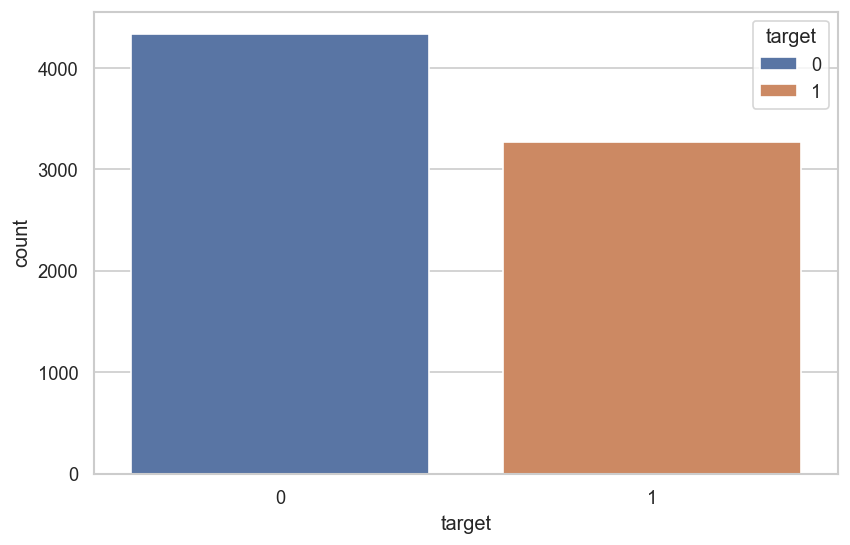

In [6]:
# Check class distribution
sns.countplot(x="target", data=df_train,hue=df_train['target'])
plt.show()

In [7]:
print(f'Number of unique values in keyword = {df_train["keyword"].nunique()} (Training) - {df_test["keyword"].nunique()} (Test)')
print(f'Number of unique values in location = {df_train["location"].nunique()} (Training) - {df_test["location"].nunique()} (Test)')

Number of unique values in keyword = 222 (Training) - 222 (Test)
Number of unique values in location = 3342 (Training) - 1603 (Test)


Figure saved: figs/5511_module4/top_20_keywords_per_class.png


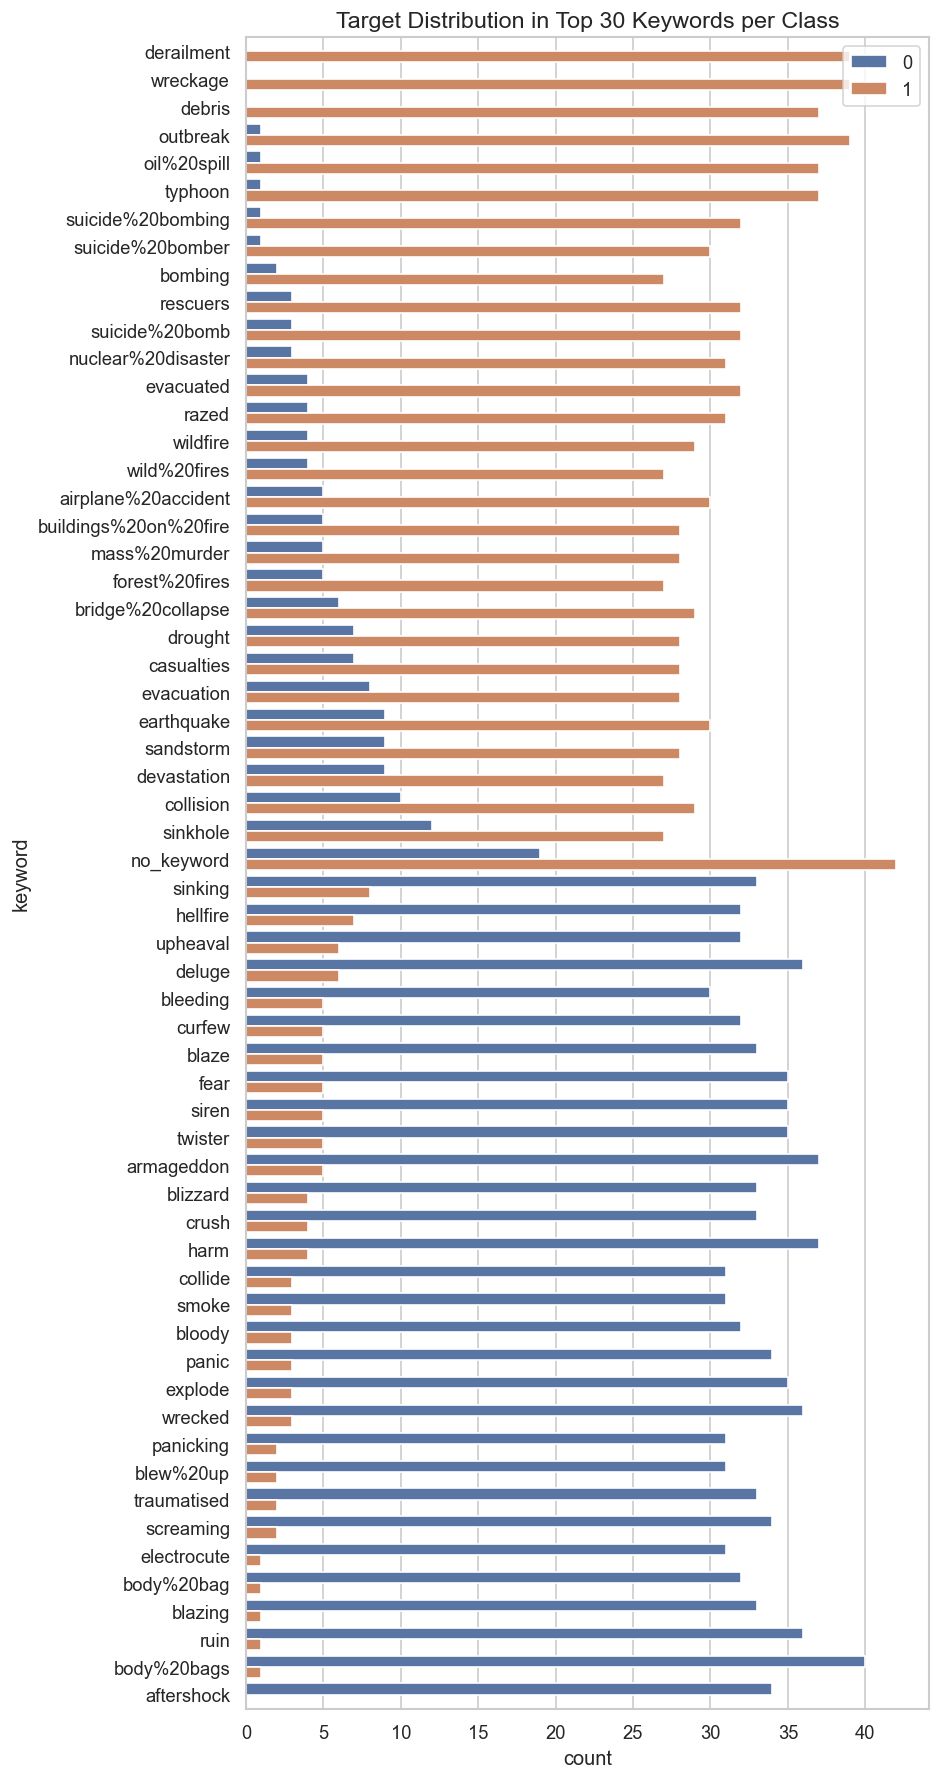

In [8]:
# Get top 20 keywords for each target class
num_keywords = 30
top_disaster = df_train[df_train['target'] == 1]['keyword'].value_counts().head(num_keywords).index
top_non_disaster = df_train[df_train['target'] == 0]['keyword'].value_counts().head(num_keywords).index
top_keywords = (list(top_disaster) + list(top_non_disaster))

# Filter the dataframe to only include these keywords
df_filtered = df_train[df_train['keyword'].isin(top_keywords)].copy()
df_filtered.loc[:, 'target_mean'] = df_filtered.groupby('keyword')['target'].transform('mean')

fig = plt.figure(figsize=(8, num_keywords *.5))  # Adjusted height for potentially up to 40 keywords

sns.countplot(y=df_filtered.sort_values(by='target_mean', ascending=False)['keyword'],
              hue=df_filtered.sort_values(by='target_mean', ascending=False)['target'])

plt.legend(loc=1)
plt.title(f'Target Distribution in Top {num_keywords} Keywords per Class')
plt.tight_layout()
save_figure("top_20_keywords_per_class")
plt.show()

The meta features used for the analysis are:
- word_count number of words in text
- unique_word_count number of unique words in text
- stop_word_count number of stop words in text
- url_count number of urls in text
- mean_word_length average character count in words
- char_count number of characters in text
- punctuation_count number of punctuations in text
- hashtag_count number of hashtags (#) in text
- mention_count number of mentions (@) in text

In [9]:
# word_count
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))
df_test['word_count'] = df_test['text'].apply(lambda x: len(str(x).split()))

# unique_word_count
df_train['unique_word_count'] = df_train['text'].apply(lambda x: len(set(str(x).split())))
df_test['unique_word_count'] = df_test['text'].apply(lambda x: len(set(str(x).split())))

# stop_word_count
df_train['stop_word_count'] = df_train['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS]))
df_test['stop_word_count'] = df_test['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS]))

# url_count
df_train['url_count'] = df_train['text'].apply(lambda x: len([w for w in str(x).lower().split() if 'http' in w or 'https' in w]))
df_test['url_count'] = df_test['text'].apply(lambda x: len([w for w in str(x).lower().split() if 'http' in w or 'https' in w]))

# mean_word_length
df_train['mean_word_length'] = df_train['text'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))
df_test['mean_word_length'] = df_test['text'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))

# char_count
df_train['char_count'] = df_train['text'].apply(lambda x: len(str(x)))
df_test['char_count'] = df_test['text'].apply(lambda x: len(str(x)))

# punctuation_count
df_train['punctuation_count'] = df_train['text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))
df_test['punctuation_count'] = df_test['text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

# hashtag_count
df_train['hashtag_count'] = df_train['text'].apply(lambda x: len([c for c in str(x) if c == '#']))
df_test['hashtag_count'] = df_test['text'].apply(lambda x: len([c for c in str(x) if c == '#']))

# mention_count
df_train['mention_count'] = df_train['text'].apply(lambda x: len([c for c in str(x) if c == '@']))
df_test['mention_count'] = df_test['text'].apply(lambda x: len([c for c in str(x) if c == '@']))

Figure saved: figs/5511_module4/meta_features_target_distribution.png


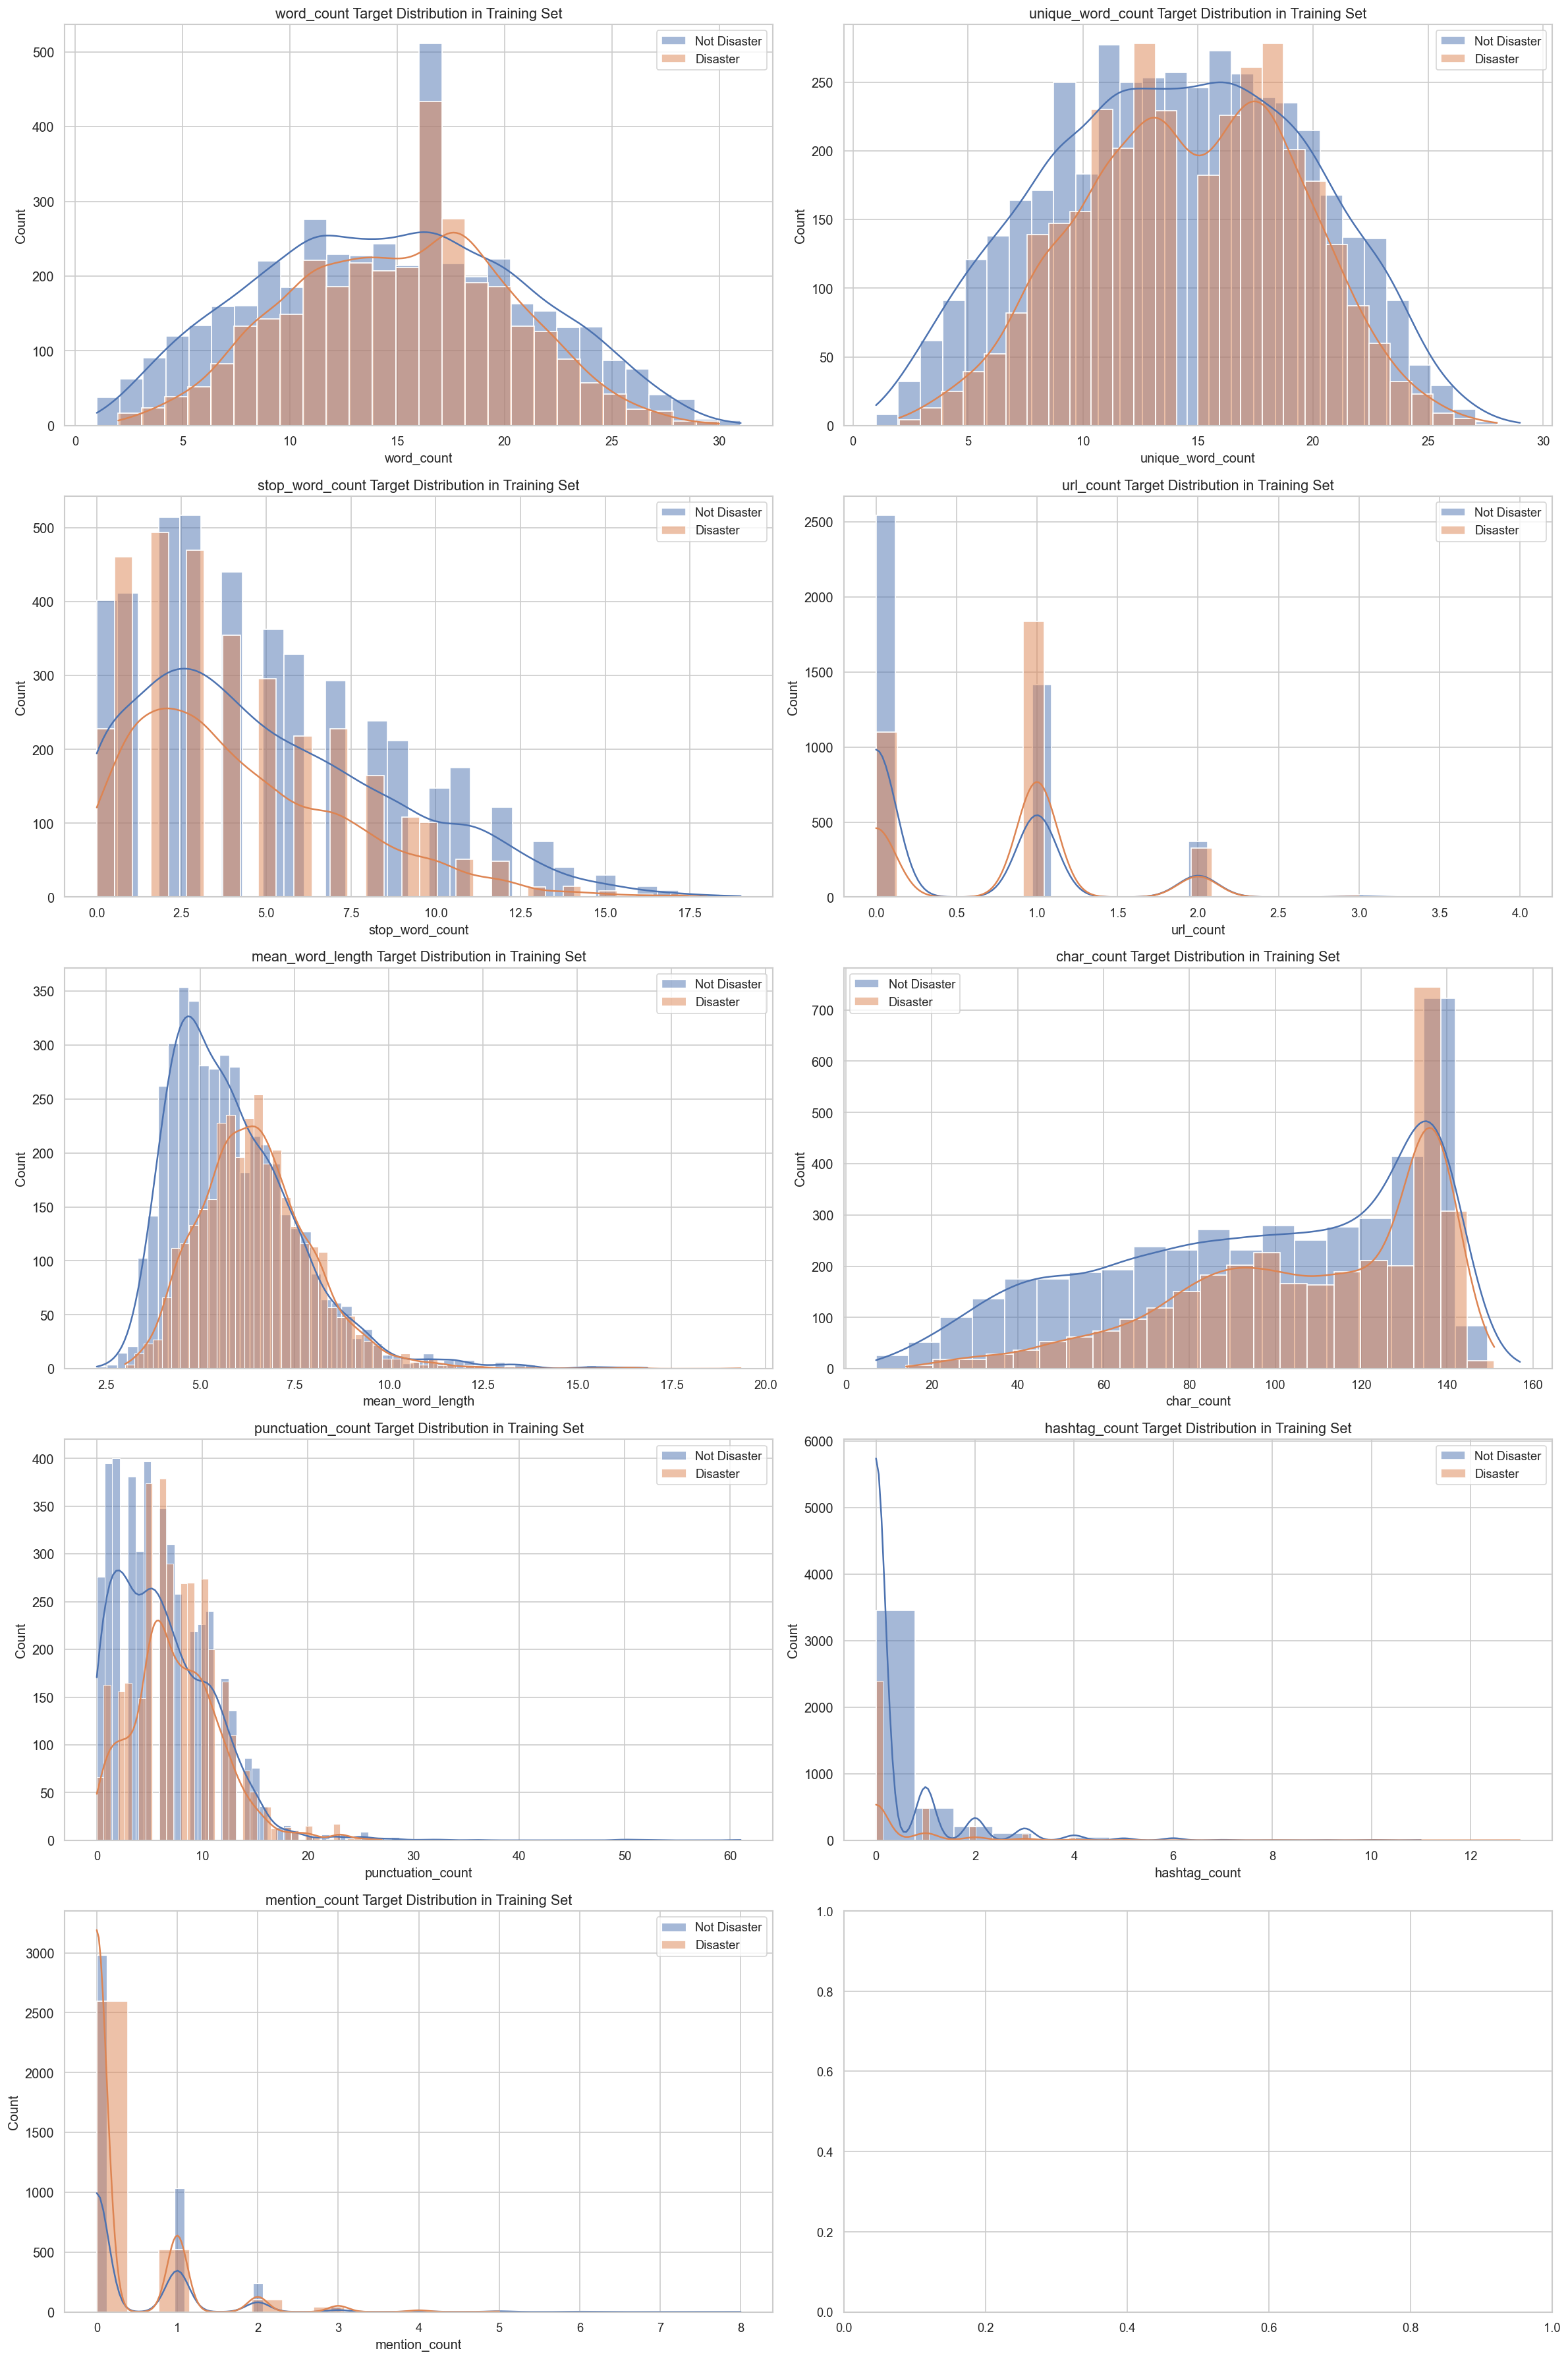

In [10]:
METAFEATURES = ['word_count', 'unique_word_count', 'stop_word_count', 'url_count', 'mean_word_length',
                'char_count', 'punctuation_count', 'hashtag_count', 'mention_count']
DISASTER_TWEETS = df_train['target'] == 1

fig, axes = plt.subplots(ncols=2, nrows=int(len(METAFEATURES)/2 +.5), figsize=(20, 30))

for i, feature in enumerate(METAFEATURES):
    r,c = i //2, i %2
    sns.histplot(df_train.loc[~DISASTER_TWEETS][feature], kde=True, label='Not Disaster', ax=axes[r][c])
    sns.histplot(df_train.loc[DISASTER_TWEETS][feature], kde=True, label='Disaster', ax=axes[r][c])
    axes[r][c].tick_params(axis='y', labelsize=12)
    axes[r][c].legend()
    axes[r][c].set_title(f'{feature} Target Distribution in Training Set', fontsize=13)
plt.tight_layout()
save_figure("meta_features_target_distribution")
plt.show()

In [11]:
# Analyse bigrams
# Generate ngrams for each tweet and count the number of times each ngram appears in each class.
def generate_ngrams(text, n_gram=1):
    token = [token for token in text.lower().split(' ') if token != '' if token not in STOPWORDS]
    ngrams = zip(*[token[i:] for i in range(n_gram)])
    return [' '.join(ngram) for ngram in ngrams]

N = 100

# Unigrams
disaster_unigrams = defaultdict(int)
nondisaster_unigrams = defaultdict(int)

for tweet in df_train[DISASTER_TWEETS]['text']:
    for word in generate_ngrams(tweet):
        disaster_unigrams[word] += 1

for tweet in df_train[~DISASTER_TWEETS]['text']:
    for word in generate_ngrams(tweet):
        nondisaster_unigrams[word] += 1

df_disaster_unigrams = pd.DataFrame(sorted(disaster_unigrams.items(), key=lambda x: x[1])[::-1])
df_nondisaster_unigrams = pd.DataFrame(sorted(nondisaster_unigrams.items(), key=lambda x: x[1])[::-1])

# Bigrams
disaster_bigrams = defaultdict(int)
nondisaster_bigrams = defaultdict(int)

for tweet in df_train[DISASTER_TWEETS]['text']:
    for word in generate_ngrams(tweet, n_gram=2):
        disaster_bigrams[word] += 1

for tweet in df_train[~DISASTER_TWEETS]['text']:
    for word in generate_ngrams(tweet, n_gram=2):
        nondisaster_bigrams[word] += 1

df_disaster_bigrams = pd.DataFrame(sorted(disaster_bigrams.items(), key=lambda x: x[1])[::-1])
df_nondisaster_bigrams = pd.DataFrame(sorted(nondisaster_bigrams.items(), key=lambda x: x[1])[::-1])

Figure saved: figs/5511_module4/top_bigrams.png


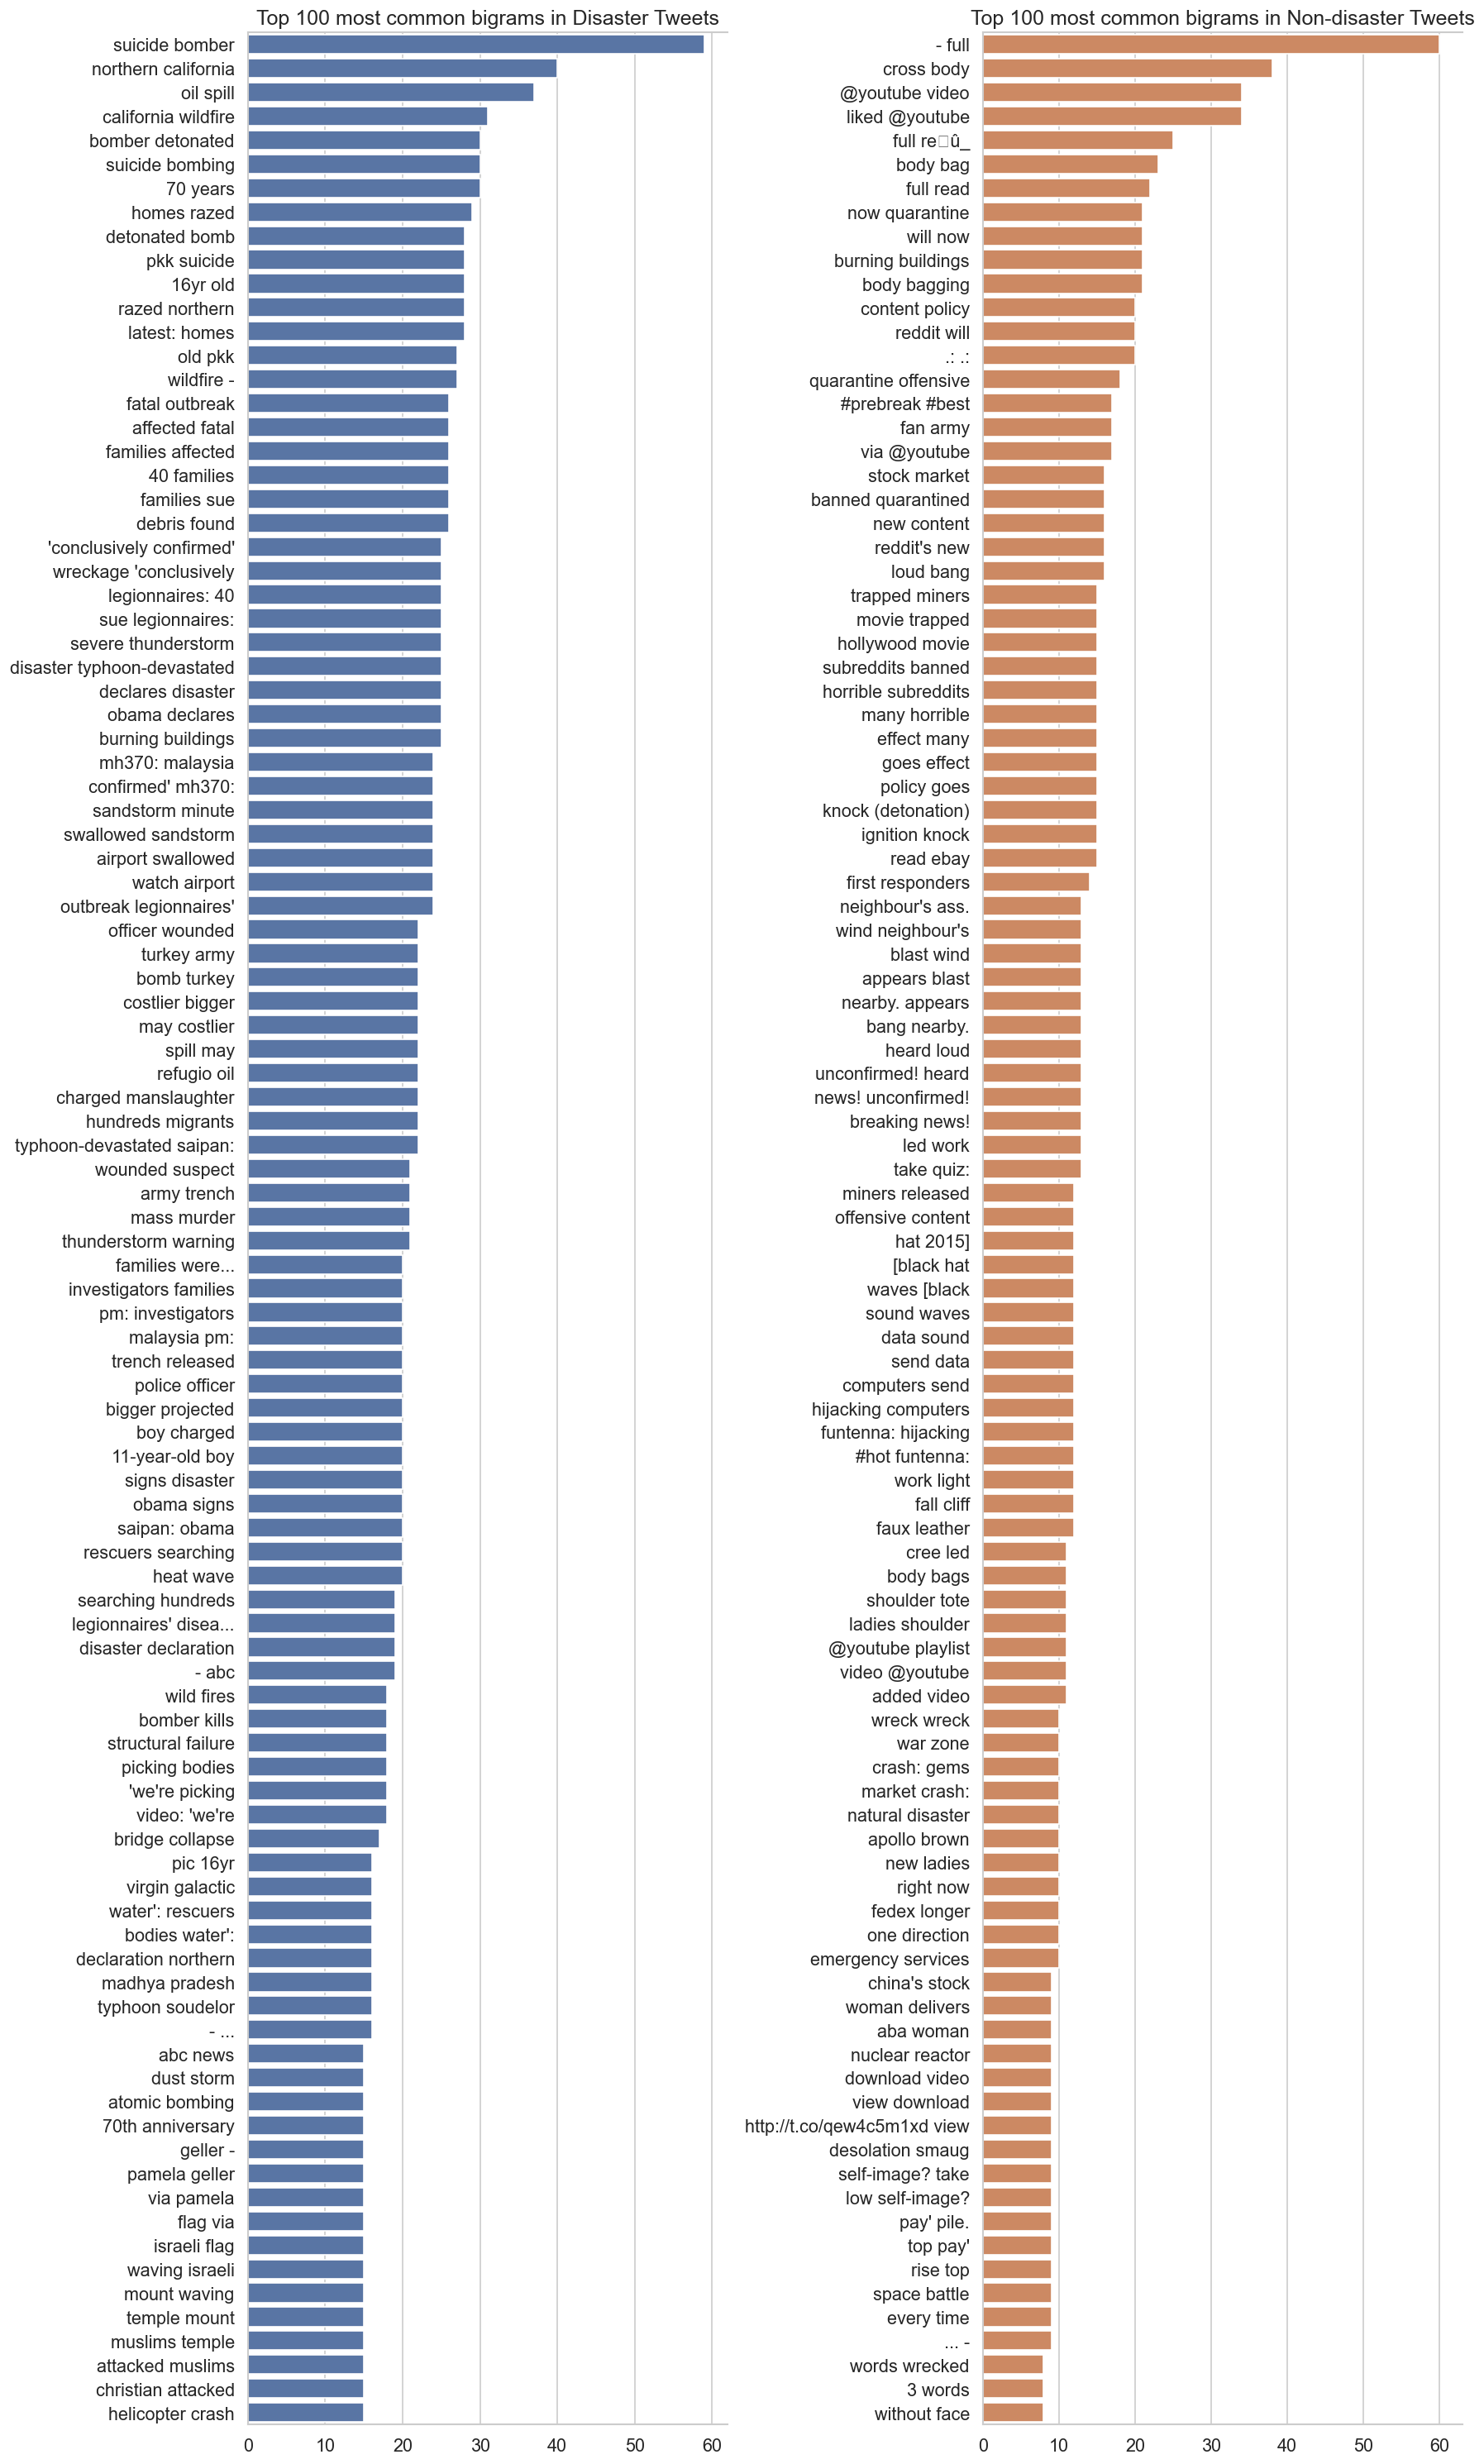

In [12]:
fig, axes = plt.subplots(ncols=2, figsize=(15, 25))

sns.barplot(y=df_disaster_bigrams[0].values[:N], x=df_disaster_bigrams[1].values[:N], ax=axes[0], color=sns.color_palette("deep")[0])
sns.barplot(y=df_nondisaster_bigrams[0].values[:N], x=df_nondisaster_bigrams[1].values[:N], ax=axes[1], color=sns.color_palette("deep")[1])

for i in range(2):
    axes[i].spines['right'].set_visible(False)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', labelsize=13)
    axes[i].tick_params(axis='y', labelsize=13)

axes[0].set_title(f'Top {N} most common bigrams in Disaster Tweets', fontsize=15)
axes[1].set_title(f'Top {N} most common bigrams in Non-disaster Tweets', fontsize=15)
warnings.filterwarnings('ignore', message='Glyph.*missing from font.*')

plt.tight_layout()
save_figure("top_bigrams")
plt.show()

In [13]:
# Mislabelled Texts
df_mislabeled = df_train.groupby(['text']).nunique().sort_values(by='target', ascending=False)
df_mislabeled = df_mislabeled[df_mislabeled['target'] > 1]['target']
print("There are ", df_mislabeled.shape[0], " mislabelled tweets. Meaning there are duplicates with differing labels in the training set.\n")
mislabelled_duplicates = df_mislabeled.index.tolist()
mislabelled_duplicates

There are  18  mislabelled tweets. Meaning there are duplicates with differing labels in the training set.



['like for the music video I want some real action shit like burning buildings and police chases not some weak ben winston shit',
 'Hellfire! We don\x89Ûªt even want to think about it or mention it so let\x89Ûªs not do anything that leads to it #islam!',
 "The Prophet (peace be upon him) said 'Save yourself from Hellfire even if it is by giving half a date in charity.'",
 'In #islam saving a person is equal in reward to saving all humans! Islam is the opposite of terrorism!',
 'To fight bioterrorism sir.',
 'Who is bringing the tornadoes and floods. Who is bringing the climate change. God is after America He is plaguing her\n \n#FARRAKHAN #QUOTE',
 '#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption',
 '#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect',
 'He came to a land which was engulfed in tribal war and turned it into a land 

In [14]:
df_train['target_relabeled'] = df_train['target'].copy()

# Not a robust way of maintaining the corrections - any change in the data would break this list. But it works for now.
correct_labels = [0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0]

for i,duplicate in enumerate(mislabelled_duplicates):
    df_train.loc[df_train['text'] == duplicate, 'target_relabeled'] = correct_labels[i]

### EDA Observations
- Note that all the tweets are in English.
- The average tweet length is 100 characters.
- The train and test data sets are taken from the same distribution.
- The distribution of the target classes is similar (see distributions of meta features for evidence), so limited requirement for stratification.
- unique_word_count, mean_word_length & punctuation_count have different distributions for disaster and non-disaster tweets.
- Bigrams for diasters tend to be more informative. Clearly, there is a need to strip punctuation and special characters.
- Interesting to note the conclusion from Guines (on Kaggle) that the distributions show tweets about diasters more likely to come from news organizations: (formal, less grammar/spelling errors); whilst those about non-disaster more likely to come from individuals: (more reference to social media, informal). This is not something I would have noted, but it seems a rational explanation for what we see in the bigram charts.
- Handling duplicates is another critical part of the pre-processing for which I thank Guines. In the wild, it would be better to manage the list of duplicates as a separate file.

## 4) Preprocessing
_Describe your preprocessing steps and reasoning for why you believe that specific preprocessing steps are suitable for this problem._

Two data preprocessing steps have already been done in EDA (replacing missing values and handling duplicates).

### Text Cleaning

There is a wealth of work already done on this set of tweets by other authors, some of which I will reuse here. The function clean(tweet) takes a tweet as input and returns a cleaned version of the tweet. I have moved the function to a separate Python file because it has more than 700 lines of regexy code. None of these regex statements are difficult or my original work - they are all taken from the Kaggle notebook by Guines. (I think this collection in turn was based on the work of others referenced in the notebook).

**_My learning and additional value here is:_**
1) Building modules in Python that I can use in Notebooks (was a basic enhancement to my Python skills, that I wanted to fix in this project.)
2) Improved knowledge on how to use regular expressions to clean text.
3) I am going to run two versions of the DistilBERT model, one with the original text and one with the cleaned text. Then I will compare the results to understand the impact of the cleaning. The DistilBERT model has its own built-in pre-processor and achieves an F1 metric on the Validation dataset of 80%, so this is the baseline to see whether the other cleaning steps taken truly improve the result.

### Other preprocessing requirements

The DistilBERT model uses its own preprocessor, but for the custom GRU model I am building for comparison, further text preprocessing will be needed. This is defined in the TextPreprocessor class.
1) Tokenise the text into sequences of integers.
2) Create a fixed length sequence of integers.

In [15]:
# clean is a function in my module nlp that executes 700+ regex statements (for details see nlp.py and referenced Kaggle Notebook in citations)

# fullu_clean is an additional cleaning to prepare the text for tokenization and embedding.
def fully_clean_tweet(tweet, stopwords_list=None):
    # Clean text data for in preparation for tokenization and embedding.
    text = tweet.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = ' '.join(text.split())
    words = text.split()
    tweet = ' '.join([word for word in words if word not in stopwords_list])

    return tweet

def fully_clean(df):
    df['text_cleaned'] = df['text'].apply(lambda s : clean_tweet(s))
    df['fully_cleaned'] = df['text_cleaned'].apply(lambda s : fully_clean_tweet(s,STOPWORDS))
    return df

df_train = fully_clean(df_train)
df_test = fully_clean(df_test)
display(df_train[['text','text_cleaned','fully_cleaned']].head(20))

,text,text_cleaned,fully_cleaned
0,Our Deeds are the Reason of this #earthquake M...,Our Deeds are the Reason of this # earthquake ...,deeds reason earthquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,Forest fire near La Ronge Sask . Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,All residents asked to ' shelter in place ' ar...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...","13,000 people receive # wildfires evacuation o...",13000 people receive wildfires evacuation orde...
4,Just got sent this photo from Ruby #Alaska as ...,Just got sent this photo from Ruby # Alaska as...,got sent photo ruby alaska smoke wildfires pou...
5,#RockyFire Update => California Hwy. 20 closed...,# Rocky Fire Update = > California Hwy . 20 cl...,rocky fire update california hwy 20 closed dir...
6,#flood #disaster Heavy rain causes flash flood...,# flood # disaster Heavy rain causes flash flo...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,I am on top of the hill and I can see a fire i...,top hill see fire woods
8,There's an emergency evacuation happening now ...,There is an emergency evacuation happening now...,emergency evacuation happening now building ac...
9,I'm afraid that the tornado is coming to our a...,I am afraid that the tornado is coming to our ...,afraid tornado coming area


Note: Looking at the text in the table above, it looks like the cleaning in 'fully_cleaned' has gone too far. Maybe good for some applications where we are extracting meaning. In this case, it probably has destroyed too much of the signal for the models to differentiate between Disaster and Non-disaster tweets.

### TextPreprocessor - required for GRU model
The DistilBERT model uses its own preprocessor, but for the custom GRU model I am building for comparison, text preprocessing will be needed.

In [16]:
class TextPreprocessor:
    """Text preprocessing for GRU model"""

    def __init__(self, vocab_size=20000, max_length=128):
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.tokenizer = None

    def fit_tokenizer(self, texts):
        """Fit tokenizer on training texts"""
        self.tokenizer = Tokenizer(
            num_words=self.vocab_size,
            oov_token='<OOV>',  # Out of vocabulary token
            lower=True,
            split=' ',
            char_level=False,
            filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
        )
        self.tokenizer.fit_on_texts(texts)
        print(f"Tokenizer fitted on {len(texts)} texts")
        print(f"Word index size: {len(self.tokenizer.word_index)}")

    def transform_texts(self, texts):
        """Transform texts to sequences"""
        if self.tokenizer is None:
            raise ValueError("Tokenizer not fitted. Call fit_tokenizer first.")
        # Convert texts to sequences
        sequences = self.tokenizer.texts_to_sequences(texts)
        # Pad sequences to fixed length
        padded = pad_sequences(
            sequences,
            maxlen=self.max_length,
            padding='post',
            truncating='post'
        )
        return padded

    def fit_transform(self, texts):
        """Fit tokenizer and transform texts"""
        self.fit_tokenizer(texts)
        return self.transform_texts(texts)

    def transform(self, texts):
        """Transform texts using the already fitted tokenizer"""
        if self.tokenizer is None:
            raise ValueError("Tokenizer not fitted. Call fit_transform first.")
        return self.transform_texts(texts)

## 5) Model Architecture and Training
_Describe your model architecture and reasoning for why you believe that specific architecture would be suitable for this problem._
_Build and train your sequential neural network model (You may use any RNN family neural network, including advanced architectures LSTM, GRU, bidirectional RNN, etc.)._

### Steps
1) Create functions to manage results dataframe and save to file
2) Setup Experiment Class, which allows easy instantiation of experiments with different parameters and differing models.
3) Run training and evaluation for each experiment: initially with the provided DistilBERT model, then with the custom GRU model.
4) Save the best model from each experiment and its weights to file, and record the results in the results dataframe.

### Architecture Selection
-DistilBERT is a state-of-the-art model for NLP tasks. It is a small, fast, and cheap model that is well suited for this problem.

-The GRU model is a simple RNN model that I am building for comparison. It is a simple model that I am using to understand more about how to construct such RNNs. I want to try to walk before attempting to run. The NLP task here seems reasonably straightforward, so even if it doesn't achieve great results, it should work.


### Create Functions to manage results dataframe and save to file
This creation of a results data frame is a based on learning from my last project, having an efficient way to capture, store and revisit results is a valuable tooling for this kind of work.

In [17]:
def initialize_results_df(output_dir=OUTPUT_DIR):
    """
    Initialize results_df by loading from the latest file or creating new one
    """
    global results_df
    loaded_df = load_latest_results_df(output_dir)
    if loaded_df is not None:
        results_df = loaded_df
    else:
        results_df = pd.DataFrame(columns=[
            'experiment', # Store the experiment name
            'model_type', # The name of the model used
            'input' # the column name of the input tweets (text, text_cleaned, fully_cleaned)
            'target', # The name of the target column ('target', 'target_relabeled')
            'dataset', # are we working on the train or the validation set?
            'date', # when did this experiment run?
            'accuracy', # metrics
            'precision',
            'recall',
            'f1_score',
            'confusion_matrix', # filename of the figure
            'best_model' # filename of the best model from the experiment
        ])

    return results_df

def update_results_dataframe(results_dict, results_df=None):
    """
    results_dict: Dictionary containing metrics and metadata from evaluate_model_performance
    existing_df: Existing results dataframe (None if creating new one)
    """

    if results_df is None or results_df.empty:
        print("Creating new results dataframe")
        results_df = pd.DataFrame([results_dict])
    else:
        mask = (results_df['experiment'] == results_dict['experiment']) & (results_df['dataset'] == results_dict['dataset'])
        if mask.any():
            for column, value in results_dict.items():
                results_df.loc[mask, column] = value
        else:
            results_df = pd.concat([results_df, pd.DataFrame([results_dict])], ignore_index=True)

    return results_df

def save_results_to_csv(results_df, output_dir=OUTPUT_DIR):
    timestamp = datetime.now().strftime("%Y%m%d")
    filename = f"results_{timestamp}.csv"
    filepath = os.path.join(output_dir, filename)
    results_df.to_csv(filepath, index=False)
    print(f"Results saved to: {filepath}")
    return filepath

def load_latest_results_df(output_dir=OUTPUT_DIR, pattern="*results*.csv"):
    """
    Load the most recent results CSV file from the output directory
    """
    # Find all CSV files matching the pattern
    pattern_path = output_dir / pattern
    csv_files = glob.glob(str(pattern_path))

    if not csv_files:
        print(f"No results files found in {output_dir} matching pattern '{pattern}'")
        return None
    # Sort files by modification time (most recent first)
    csv_files.sort(key=os.path.getmtime, reverse=True)
    latest_file = csv_files[0]

    try:
        # Load the CSV file
        results_df = pd.read_csv(latest_file)
        print(f"Loaded results from: {latest_file}")
        return results_df

    except Exception as e:
        print(f"Error loading {latest_file}: {e}")
        return None

initialize_results_df()

No results files found in outputs/5511_module4 matching pattern '*results*.csv'


,experiment,model_type,inputtarget,dataset,date,accuracy,precision,recall,f1_score,confusion_matrix,best_model


### Setup Experiment Class
The Class Experiment will be used to facilitate running multiple experiments with multiple models on differing inputs and targets. It has the following methods:
- setup_data (define input and target and train_test split)
- add_model (select DistilBERT or GRU as model and compile)
- evaluate_model_performance (evaluate model performance ,return metrics and confusion matrix)
- run (run experiment based on given parameters)

In [18]:
class Experiment():
    def __init__(self, name, model_type, input, target, learning_rate, loss, epochs, batch_size, seed=SEED, verbose=True):
        self.name = name
        self.model_type = model_type
        self.input = input
        self.target = target
        self.learning_rate = learning_rate
        self.loss = loss
        self.epochs = epochs
        self.batch_size = batch_size
        self.seed = seed
        self.preprocessor = None
        self.model = self._create_model(model_type)

        # Verify preprocessor was created for GRU models
        if model_type in ['GRU', 'simple_GRU'] and self.preprocessor is None:
            print("Warning: Preprocessor not initialized for GRU model")
            self.preprocessor = TextPreprocessor(vocab_size=20000, max_length=128)

        if verbose:
            print(f"Experiment initialized with {model_type} model")
            self.model.summary()

    def _create_model(self, model_type):
        """Create and return the specified model type"""
        if model_type == 'DistilBERT':
            return self._create_distilbert_model()
        elif model_type == 'GRU':
            return self._create_gru_model()
        # Add other model types as needed
        elif model_type == 'simple_GRU':
            return self._create_simpleGRU_model()
        else:
            raise ValueError(f"Unsupported model type: {model_type}")

    def setup_data(self, df=df_train, val_split=0.2):
        X = df[self.input]
        y = df[self.target]
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=val_split, random_state=self.seed)
        print("Starting data setup.")
        # If we have a preprocessor (for GRU model), use it to transform text data
        if hasattr(self, 'preprocessor') and self.preprocessor is not None:
            print("Applying text preprocessing for GRU model...")
            # Convert pandas Series to list for preprocessing
            X_train_texts = X_train.tolist()
            X_val_texts = X_val.tolist()

            # Fit the preprocessor on training text and transform both train/val
            X_train = self.preprocessor.fit_transform(X_train_texts)
            X_val = self.preprocessor.transform(X_val_texts)

            # Ensure the data is proper numpy arrays with correct dtype
            X_train = np.array(X_train, dtype=np.int32)
            X_val = np.array(X_val, dtype=np.int32)

        print(f"Text preprocessed - X_train shape: {X_train.shape}, dtype: {X_train.dtype}")


        # Ensure labels are proper numeric type
        y_train = np.asarray(y_train, dtype=np.float32)
        y_val = np.asarray(y_val, dtype=np.float32)

        return X_train, X_val, y_train, y_val

    def _create_distilbert_model(self):
        # Load a DistilBERT model.
        preset= "distil_bert_base_en_uncased"
        preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(preset,
                                                                           sequence_length=160,
                                                                           name="preprocessor_4_tweets"
                                                                           )
        model = keras_nlp.models.DistilBertClassifier.from_preset(preset,
                                                                  preprocessor = preprocessor,
                                                                  num_classes=2)
        # Compile
        model.compile(
            loss=self.loss,
            optimizer=Adam(learning_rate=self.learning_rate),
            metrics=["accuracy"],
        )
        return model


    def _create_gru_model(self, vocab_size=20000, max_length=128, embedding_dim=128, gru_units=128):
        """
        Create and return a GRU-based model for text classification
        """
        # Initialize preprocessor for GRU
        self.preprocessor = TextPreprocessor(vocab_size=vocab_size, max_length=max_length)

        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(max_length,), dtype=tf.int32),
            tf.keras.layers.Embedding(vocab_size, embedding_dim, mask_zero=True),
            tf.keras.layers.SpatialDropout1D(0.1),
            tf.keras.layers.Bidirectional(
                tf.keras.layers.GRU(
                    gru_units,
                    dropout=0.1,
                    recurrent_dropout=0.0,  # Keep at 0 as you had
                    return_sequences=True,
                    implementation=2,
                    reset_after=True,
                    dtype=tf.float32
                )
            ),
            tf.keras.layers.GRU(gru_units//2,
                                dropout=0.1,
                                recurrent_dropout=0.0),

            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dropout(0.1),
            tf.keras.layers.Dense(1, activation='sigmoid',
                                  kernel_initializer='glorot_uniform',
                                  bias_initializer='zeros',
                                  dtype=tf.float32)
        ])

        # Compile the model
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate),
            loss=self.loss,
            metrics=['accuracy', 'precision', 'recall']
        )
        return model

    def _create_simpleGRU_model(self, vocab_size=20000, max_length=128, embedding_dim=100, gru_units=64):
        """
        Simple, robust GRU model that actually learns both classes
        """
        self.preprocessor = TextPreprocessor(vocab_size=vocab_size, max_length=max_length)

        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(max_length,)),
            tf.keras.layers.Embedding(vocab_size, embedding_dim),
            tf.keras.layers.SpatialDropout1D(0.2),

            tf.keras.layers.GRU(gru_units, dropout=0.2, recurrent_dropout=0.0),

            tf.keras.layers.Dense(1, activation='sigmoid')
        ])

        # Much lower learning rate + different optimizer
        model.compile(
            optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        return model

    def evaluate_model_performance(self, X_data, y_true, dataset_name="Dataset", verbose=True):
        # Get predictions
        y_pred_probs = self.model.predict(X_data)
        y_pred_classes = np.argmax(y_pred_probs, axis=1)

        # Scores
        accuracy = accuracy_score(y_true, y_pred_classes),
        precision = precision_score(y_true, y_pred_classes, average='weighted'),
        recall = recall_score(y_true, y_pred_classes, average='weighted'),
        f1 =  f1_score(y_true, y_pred_classes, average='weighted')

        # Create and save confusion matrix
        cm = confusion_matrix(y_true, y_pred_classes)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=["Not Disaster", "Disaster"])

        plt.figure(figsize=(8, 6))
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"{self.name}_{self.model_type} - {dataset_name} Set", fontsize=14)

        # Save to FIG_DIR
        fig_filename = f"cm_{self.name}_{self.model_type}_{dataset_name.lower()}"
        save_figure(fig_filename)

        if verbose:
            plt.tight_layout()
            plt.show()
            # Print detailed classification report
            print(f"\n{dataset_name} Set Classification Report:")
            print("="*50)
            print(classification_report(y_true, y_pred_classes,
                                        target_names=["Not Disaster", "Disaster"]))

        # Return results as dictionary
        return {
            'experiment': self.name,
            'model_type': self.model_type,
            'input': self.input,
            'target': self.target,
            'dataset': dataset_name,
            'date': datetime.now().strftime('%Y-%m-%d'),
            'accuracy': accuracy_score(y_true, y_pred_classes),
            'precision': precision_score(y_true, y_pred_classes, average='weighted'),
            'recall': recall_score(y_true, y_pred_classes, average='weighted'),
            'f1_score': f1_score(y_true, y_pred_classes, average='weighted'),
            'confusion_matrix': fig_filename,
            'best_model':f'{self.name}_best_model.keras'
        }

    def run(self, X_train, X_val, y_train, y_val):
        # setup callbacks
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=3,
                restore_best_weights=True,
                verbose=1
            ),
            ModelCheckpoint(
                filepath=MODEL_DIR / f'{self.name}_best_model.keras',
                monitor='val_loss',
                save_best_only=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='loss',
                factor=0.5,
                patience=2,
            )
        ]

        # Fit
        history = self.model.fit(
            x=X_train,
            y=y_train,
            batch_size=self.batch_size,
            epochs=self.epochs,
            validation_data=(X_val, y_val),
            verbose=2,  # Less verbose
            callbacks=callbacks
        )
        return history


### DistilBERT Model
Text inputs need to be transformed to numeric token ids and arranged in several Tensors before being input to BERT.

The BertClassifier model can be configured with a preprocessor layer, in which case it will automatically apply preprocessing to raw inputs during fit(), predict(), and evaluate(). This is done by default when creating the model with from_preset().

We will choose DistilBERT model.that learns a distilled (approximate) version of BERT, retaining 97% performance but using only half the number of parameters ([paper](https://arxiv.org/abs/1910.01108)).

It has 40% less parameters than bert-base-uncased, runs 60% faster while preserving over 95% of BERT’s performances as measured on the GLUE language understanding benchmark. Specifically, it doesn't have token-type embeddings, pooler and retains only half of the layers from Google's BERT.

In [19]:
experiment_1 = Experiment(name='experiment_1',
                          model_type='DistilBERT',
                          input='text_cleaned',
                          target='target_relabeled',
                          learning_rate=1e-5,
                          loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                          epochs=2,
                          batch_size=32)
experiment = experiment_1
X_train, X_val, y_train, y_val = experiment.setup_data(df=df_train, val_split=0.2)
# train the model
history = experiment.run(X_train, X_val, y_train, y_val)

2025-10-09 08:41:37.952844: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-10-09 08:41:37.952892: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-10-09 08:41:37.952903: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1759995697.953101 7298254 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1759995697.953278 7298254 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Experiment initialized with DistilBERT model


Preprocessor: "preprocessor_4_tweets"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ distil_bert_tokenizer (DistilBertTokenizer)                   │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "distil_bert_text_classifier"

...

 Trainable params: 66,955,010 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

Starting data setup.
Text preprocessed - X_train shape: (6090,), dtype: object
Epoch 1/2


2025-10-09 08:41:42.507445: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



Epoch 1: val_loss improved from None to 0.38917, saving model to models/5511_module4/experiment_1_best_model.keras
191/191 - 228s - 1s/step - accuracy: 0.7941 - loss: 0.4685 - val_accuracy: 0.8437 - val_loss: 0.3892 - learning_rate: 1.0000e-05
Epoch 2/2

Epoch 2: val_loss improved from 0.38917 to 0.37709, saving model to models/5511_module4/experiment_1_best_model.keras
191/191 - 202s - 1s/step - accuracy: 0.8611 - loss: 0.3530 - val_accuracy: 0.8483 - val_loss: 0.3771 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 2.


191/191 ━━━━━━━━━━━━━━━━━━━━ 82s 421ms/step
Figure saved: figs/5511_module4/cm_experiment_1_DistilBERT_training.png


<Figure size 960x720 with 0 Axes>

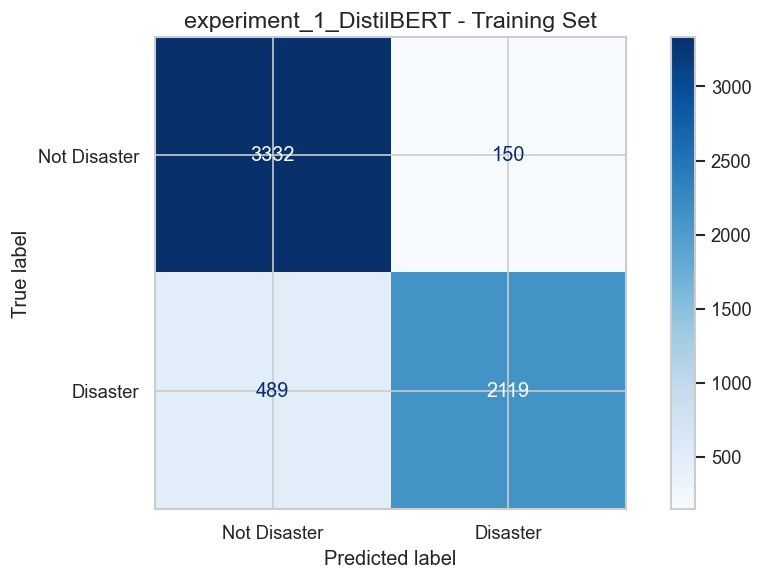


Training Set Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.87      0.96      0.91      3482
    Disaster       0.93      0.81      0.87      2608

    accuracy                           0.90      6090
   macro avg       0.90      0.88      0.89      6090
weighted avg       0.90      0.90      0.89      6090

Creating new results dataframe
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 453ms/step
Figure saved: figs/5511_module4/cm_experiment_1_DistilBERT_validation.png


<Figure size 960x720 with 0 Axes>

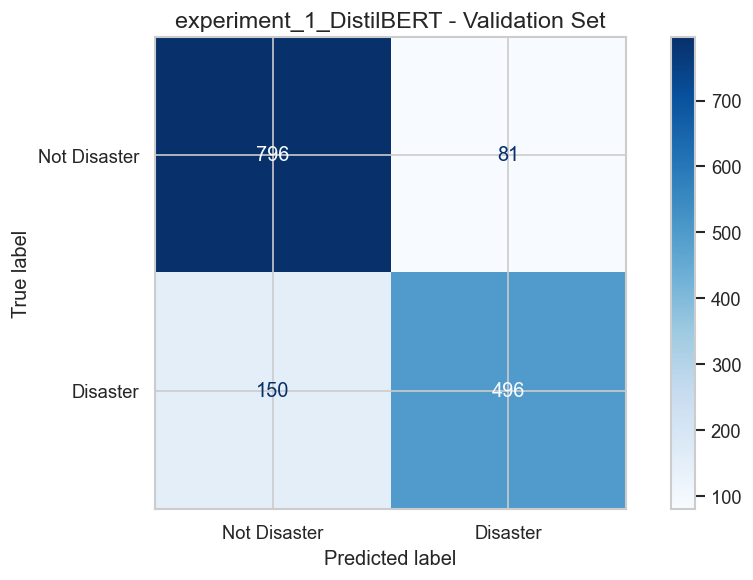


Validation Set Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.84      0.91      0.87       877
    Disaster       0.86      0.77      0.81       646

    accuracy                           0.85      1523
   macro avg       0.85      0.84      0.84      1523
weighted avg       0.85      0.85      0.85      1523



,experiment,model_type,input,target,dataset,date,accuracy,precision,recall,f1_score,confusion_matrix,best_model
0,experiment_1,DistilBERT,text_cleaned,target_relabeled,Training,2025-10-09,0.895074,0.898518,0.895074,0.893862,cm_experiment_1_DistilBERT_training,experiment_1_best_model.keras
1,experiment_1,DistilBERT,text_cleaned,target_relabeled,Validation,2025-10-09,0.848326,0.849149,0.848326,0.846917,cm_experiment_1_DistilBERT_validation,experiment_1_best_model.keras


In [20]:
# After each experiment
train_results = experiment.evaluate_model_performance(X_train, y_train, "Training")
results_df = update_results_dataframe(train_results, results_df)

val_results = experiment.evaluate_model_performance(X_val, y_val, "Validation")
results_df = update_results_dataframe(val_results, results_df)

display(results_df)

### Custom Model

In [21]:
experiment_2 = Experiment(name='experiment_2',
                          model_type='GRU',
                          input='text_cleaned',
                          target='target_relabeled',
                          learning_rate=0.001,
                          loss='binary_crossentropy',
                          epochs=10,
                          batch_size=32)
experiment = experiment_2
X_train, X_val, y_train, y_val = experiment.setup_data(df=df_train, val_split=0.2)
# train the model
history = experiment.run(X_train, X_val, y_train, y_val)

Experiment initialized with GRU model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 128, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 128, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128, 256)       │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,826,497 (10.78 MB)

 Trainable params: 2,826,369 (10.78 MB)

 Non-trainable params: 128 (512.00 B)

Starting data setup.
Applying text preprocessing for GRU model...
Tokenizer fitted on 6090 texts
Word index size: 14775
Text preprocessed - X_train shape: (6090, 128), dtype: int32
Epoch 1/10

Epoch 1: val_loss improved from None to 0.68175, saving model to models/5511_module4/experiment_2_best_model.keras
191/191 - 38s - 197ms/step - accuracy: 0.5302 - loss: 0.7219 - precision: 0.4406 - recall: 0.3597 - val_accuracy: 0.5758 - val_loss: 0.6817 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10

Epoch 2: val_loss did not improve from 0.68175
191/191 - 31s - 164ms/step - accuracy: 0.5304 - loss: 0.7177 - precision: 0.4290 - recall: 0.2918 - val_accuracy: 0.4242 - val_loss: 0.6977 - val_precision: 0.4242 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10

Epoch 3: val_loss did not improve from 0.68175
191/191 - 32s - 168ms/step - accuracy: 0.5310 - loss: 0.7190 - precision: 0.4308 - recall: 0.2960 - val_accuracy: 0.5758 - val_loss: 0.6842 - val_pr

191/191 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step
Figure saved: figs/5511_module4/cm_experiment_2_GRU_training.png


/Users/seancoffey/PycharmProjects/ML_course/.venv-3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 960x720 with 0 Axes>

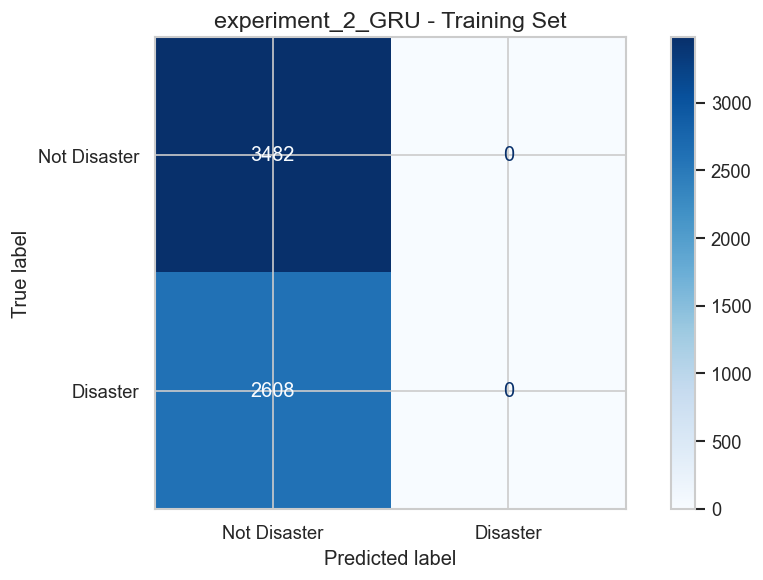


Training Set Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.57      1.00      0.73      3482
    Disaster       0.00      0.00      0.00      2608

    accuracy                           0.57      6090
   macro avg       0.29      0.50      0.36      6090
weighted avg       0.33      0.57      0.42      6090

 2/48 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step

/Users/seancoffey/PycharmProjects/ML_course/.venv-3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/seancoffey/PycharmProjects/ML_course/.venv-3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/seancoffey/PycharmProjects/ML_course/.venv-3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step
Figure saved: figs/5511_module4/cm_experiment_2_GRU_validation.png


/Users/seancoffey/PycharmProjects/ML_course/.venv-3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 960x720 with 0 Axes>

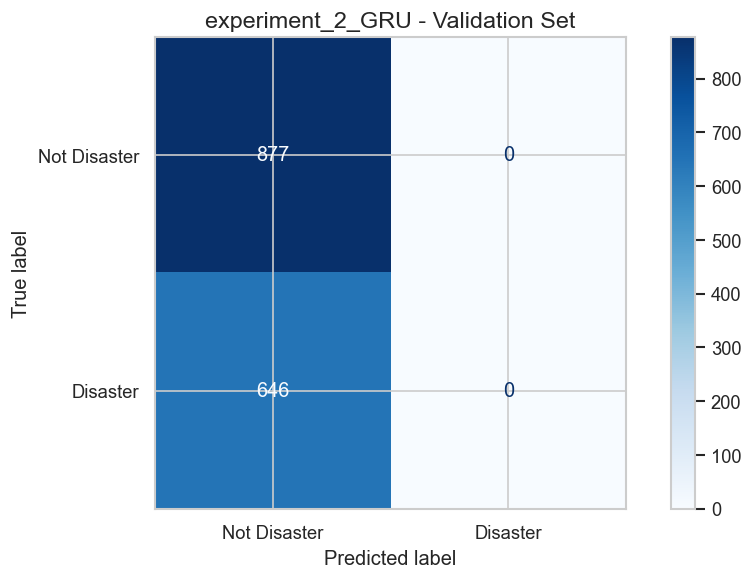


Validation Set Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.58      1.00      0.73       877
    Disaster       0.00      0.00      0.00       646

    accuracy                           0.58      1523
   macro avg       0.29      0.50      0.37      1523
weighted avg       0.33      0.58      0.42      1523



/Users/seancoffey/PycharmProjects/ML_course/.venv-3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/seancoffey/PycharmProjects/ML_course/.venv-3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/seancoffey/PycharmProjects/ML_course/.venv-3.11/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

,experiment,model_type,input,target,dataset,date,accuracy,precision,recall,f1_score,confusion_matrix,best_model
0,experiment_1,DistilBERT,text_cleaned,target_relabeled,Training,2025-10-09,0.895074,0.898518,0.895074,0.893862,cm_experiment_1_DistilBERT_training,experiment_1_best_model.keras
1,experiment_1,DistilBERT,text_cleaned,target_relabeled,Validation,2025-10-09,0.848326,0.849149,0.848326,0.846917,cm_experiment_1_DistilBERT_validation,experiment_1_best_model.keras
2,experiment_2,GRU,text_cleaned,target_relabeled,Training,2025-10-09,0.571757,0.326906,0.571757,0.415975,cm_experiment_2_GRU_training,experiment_2_best_model.keras
3,experiment_2,GRU,text_cleaned,target_relabeled,Validation,2025-10-09,0.575837,0.331588,0.575837,0.420841,cm_experiment_2_GRU_validation,experiment_2_best_model.keras


In [22]:
# After each experiment
train_results = experiment.evaluate_model_performance(X_train, y_train, "Training")
results_df = update_results_dataframe(train_results, results_df)

val_results = experiment.evaluate_model_performance(X_val, y_val, "Validation")
results_df = update_results_dataframe(val_results, results_df)

display(results_df)

In [24]:
save_results_to_csv(results_df)

Results saved to: outputs/5511_module4/results_20251009.csv


'outputs/5511_module4/results_20251009.csv'

## 7) Conclusion
_Discuss and interpret results as well as learnings and takeaways. What did and did not help improve the performance of your models? What improvements could you try in the future?_

### Model Performance - custom_GRU model

Extremely frustrating that I could not get my custom GRU model to predict anything. Having spent hours and hours trying to figure it out, I will go with the results I got from the DistilBERT model. Potential issues with the custom GRU model:
1) Class imbalance - but the 57% / 43% seems reasonable and works with the DistilBERT model
2) Learning Rate issues - but I tried many and it made no difference
3) Text preprocessing - the initial cleaning is the same as for the DistilBERT model, so that can't be the problem. However, the tokenizer may be doing things that I am not aware about. I wasn't able to really investigate this. I did try using the DistilBERT preprocessor, but there are too many differences between what the models require.
4) Loss Function - maybe the binary cross entropy is not the right one for this problem. Not sure what else to try.
5) Model Architecture - I tried a simple architecture to check ("simple_GRU") and it did not work. Maybe there is something wrong with what I did, this is all very new to me. Potentially, GRU is just not the right model for this problem and I should have tried LSTM. Again, out of time.

Nonetheless, I learned much about the process.

### Model Performance - DistilBERT

The DistilBERT model performed well. It was able to predict the disaster class with 85% accuracy and achieved an F1 score of 0.85.
I ran out of time to implement the addition of keywords and meta-features into the model. I think that this might have helped the model to learn more about the text, but it will have to be deferred to a next step.

Likewise, it would have been interesting to try differing learning rates, batch sizes, epoch numbers and other hyperparameters.

### Personal Learning
I had set myself the objective to use this project to improve the way I set up the workflow in the Notebok and use Python to make life easier. I am happy with what I achieved:
1) Capturing and managing results in a dataframe/csv file
2) Using the Experiment Class to run multiple experiments with different models and parameters
3) Separating modules from the Notebook itself (e.g. for cleaning tweets)
4) Using the Keras NLP library to build a DistilBERT model and a GRU model.

The aspects of deep learning that I have not fully figured out how to do effectively need to be my next focus:
1) Model Tuning still seems an art form rather than a science. I do not have good grounding principals for selection of hyperparameters or achitecture design.
2) I spend a lot of time because each model run takes so long, so it becomes a real impediment to trying things out and seeing what happens
3) Issues with syntax and worse: differences in syntax within the same library are frustrating. I find myself very reliant on the AI assistant to search for solutions to these niggles. In particular: clashes between the Keras library and the tf.Keras library.

The project itself was a good fit for where I am in my learning journey. Because so much is already available about this project on Kaggle (see citations), I was able to get a really strong idea of how to tackle the challenge before I started building my own improvements. This let me focus on what I wanted to learn, at least until it all unravelled with the custom GRU model.

Some observations about the nature of the task to take forward:
1) Once again, I was surprised by the importance of EDA, the length of time it took and the detail needed to prepare before modelling
2) Text cleaning and pre-processing is clearly another art form to learn slowly and practice. Why this set of stop words vs that set of stop words? How much regex cleaning makes sense? What is the right solution for tokenization? I am pretty sure that the fully cleaned input had gone too far in text cleaning and destroyed the signal between disaster and non-diaster tweets.

In [23]:
experiment = experiment_1 # to allow selection of expriment with best results
best_classifier = experiment.model
X_test = df_test[experiment.input]
sample_submission = pd.read_csv(os.path.join(DATA_DIR,'sample_submission.csv'), sep = ',')
sample_submission["target"] = np.argmax(best_classifier.predict(X_test), axis=1)
sample_submission.describe()
sample_submission.to_csv(os.path.join(OUTPUT_DIR,"submission.csv"), index=False)

102/102 ━━━━━━━━━━━━━━━━━━━━ 43s 420ms/step


## 9) Citations

1) My startpoint was the starter notebook provided by the Keras team. https://keras.io/guides/keras_nlp/getting_started/
2) This notebook on Kaggle from Guines Evitan was extremely helpful: https://www.kaggle.com/code/gunesevitan/nlp-with-disaster-tweets-eda-cleaning-and-bert